# ** 1. Get Dataset from Kaggle**

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"bhavinpalansandiego","key":"60d9a46c338f33583075a5a75c01f89d"}'}

In [ ]:
!mkdir -p /root/.kaggle/
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c state-farm-distracted-driver-detection

100% 3.99G/4.00G [00:51<00:00, 57.3MB/s]
100% 4.00G/4.00G [00:51<00:00, 83.1MB/s]


In [ ]:
# Unzip files
!mkdir statefarm_data
!unzip -q state-farm-distracted-driver-detection.zip -d statefarm_data

# Unzip any inner zips
import os
for f in os.listdir("statefarm_data"):
    if f.endswith(".zip"):
        print("Unzipping:", f)
        !unzip -q statefarm_data/$f -d statefarm_data

# **YoLo Model based Training & Test Below**

In [ ]:
%%capture --no-display
!pip install ultralytics
!pip install split-folders
!pip install -U ipywidgets

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import os
import splitfolders
from IPython.display import display, Image
import pandas as pd

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
#model = YOLO('yolov8n-cls.pt')

model = YOLO('yolo11n-cls.pt')

In [ ]:
splitfolders.ratio("statefarm_data/imgs/train", output="statefarm_data/output", seed=1337, ratio=(0.7, 0.15, 0.15))

Copying files: 22424 files [00:08, 2554.65 files/s]


In [ ]:
results = model.train(data = 'statefarm_data/output', epochs = 10)

Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=statefarm_data/output, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0

In [ ]:
model.val()

Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n-cls summary (fused): 47 layers, 1,538,834 parameters, 0 gradients, 3.2 GFLOPs
train: /content/statefarm_data/output/train... found 15692 images in 10 classes ✅ 
val: /content/statefarm_data/output/val... found 3358 images in 10 classes ✅ 
test: /content/statefarm_data/output/test... found 3374 images in 10 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1535.8±606.0 MB/s, size: 40.3 KB)
val: Scanning /content/statefarm_data/output/val... 3358 images, 0 corrupt: 100% ━━━━━━━━━━━━ 3358/3358 6.8Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 210/210 11.1it/s 18.9s
                   all      0.996          1
Speed: 0.1ms preprocess, 1.0ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val


ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ec5d3e5fd40>
curves: []
curves_results: []
fitness: 0.9982132315635681
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9964264631271362, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9982132315635681}
save_dir: PosixPath('/content/runs/classify/val')
speed: {'preprocess': 0.10094167927430944, 'inference': 1.0297518546751685, 'loss': 0.0013295801072390797, 'postprocess': 0.0009496670623015041}
task: 'classify'
top1: 0.9964264631271362
top5: 1.0

In [ ]:
df = pd.read_csv("runs/classify/train/results.csv")
df.head(5)

,epoch,time,train/loss,metrics/accuracy_top1,metrics/accuracy_top5,val/loss,lr/pg0,lr/pg1,lr/pg2
0,1,158.114,1.08291,0.95205,0.99792,0.17015,0.000238,0.000238,0.000238
1,2,312.793,0.34202,0.96873,0.99940,0.09274,0.000429,0.000429,0.000429
2,3,466.979,0.25854,0.97588,0.99940,0.07341,0.000572,0.000572,0.000572
3,4,621.974,0.21306,0.98362,0.99970,0.04804,0.000502,0.000502,0.000502
4,5,772.423,0.16532,0.98749,1.00000,0.03908,0.000431,0.000431,0.000431


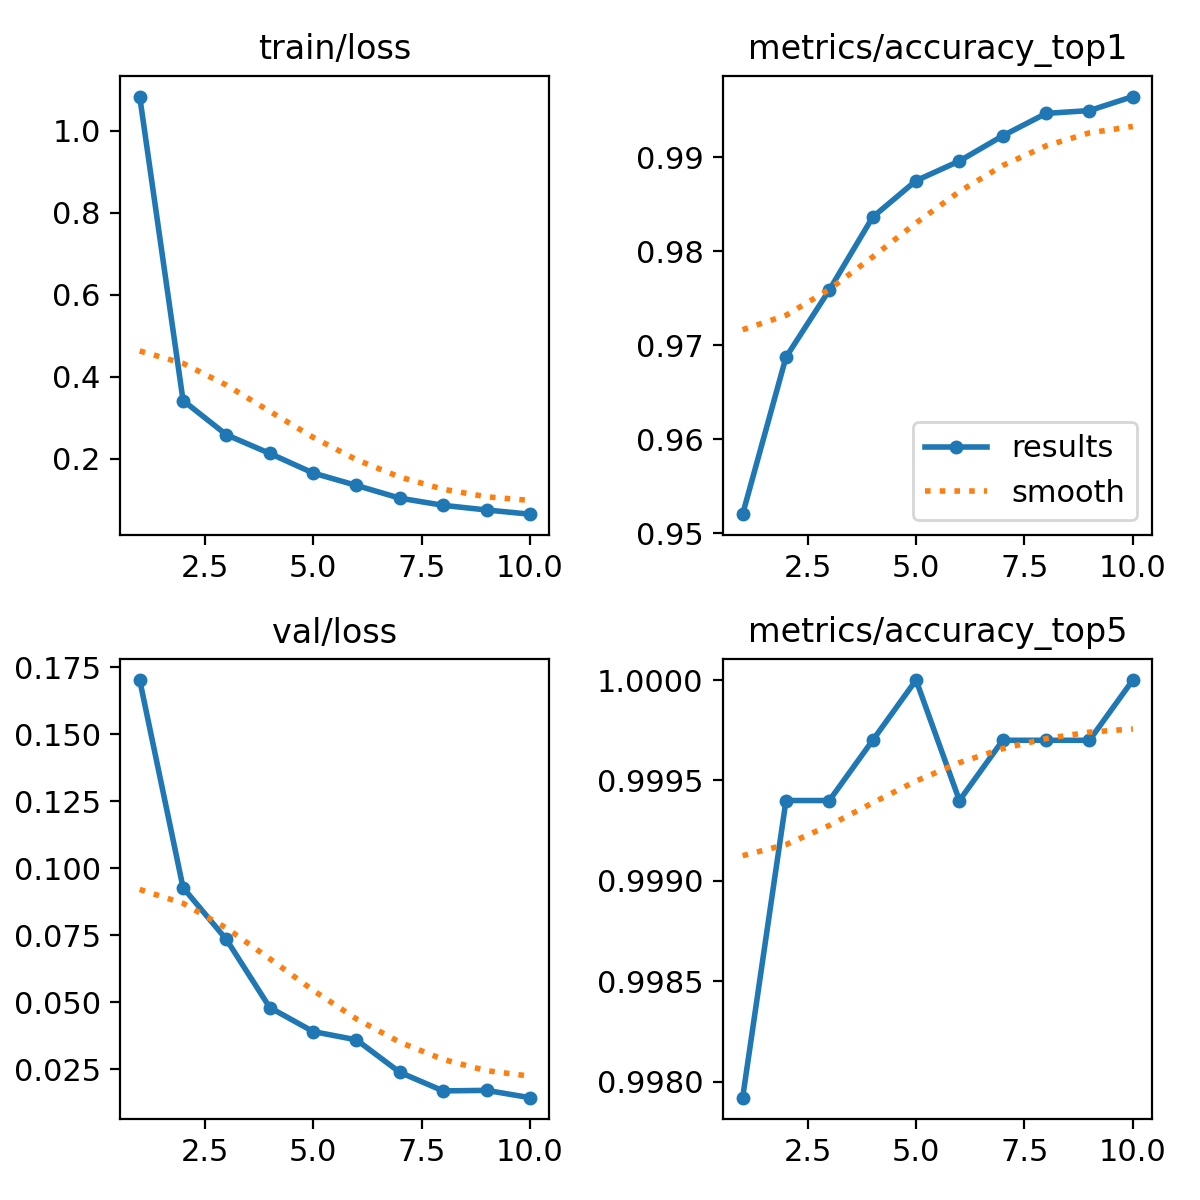

In [ ]:
Image("runs/classify/train/results.png")

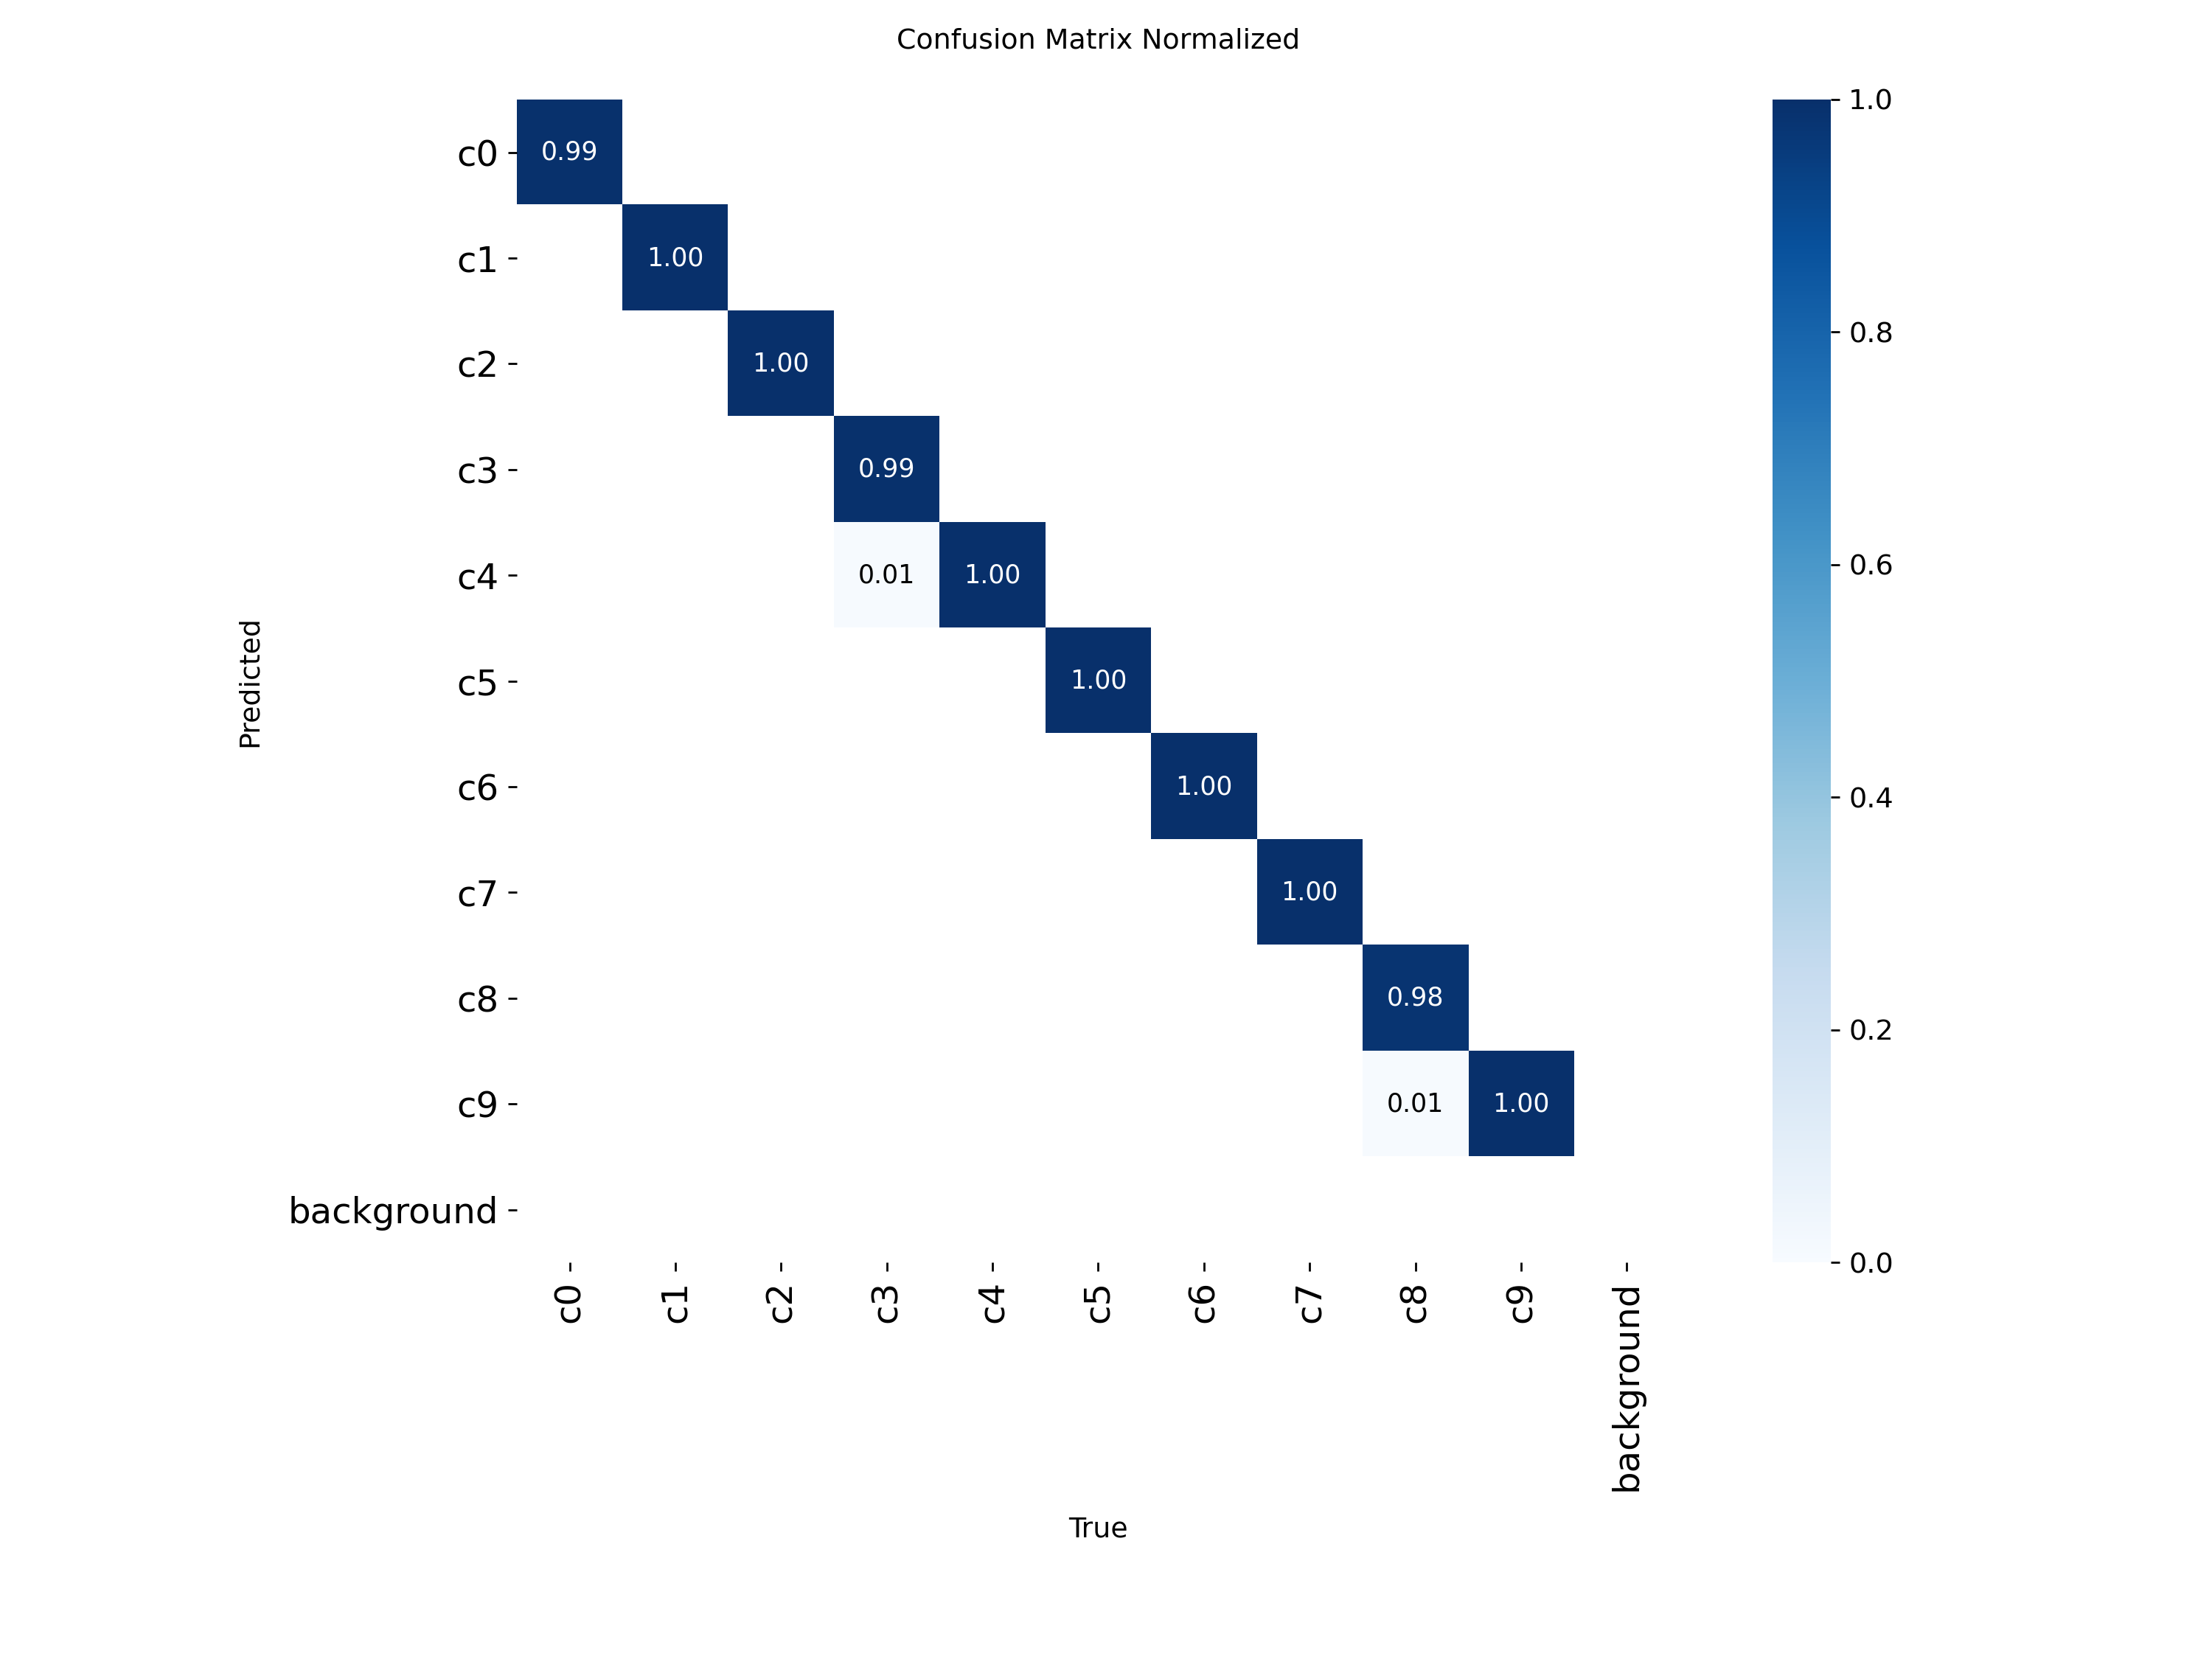

In [ ]:
Image("runs/classify/train/confusion_matrix_normalized.png")

In [ ]:
path = "statefarm_data/imgs/test/"
model_weights = "/statefarm_data/working/runs/classify/train/weights/best.pt"
pred = [(path+i,model.predict(path+i, model = model_weights)[0].probs.top1) for i in os.listdir(path)[:45]]


image 1/1 /content/statefarm_data/imgs/test/img_14409.jpg: 224x224 c4 1.00, c9 0.00, c8 0.00, c6 0.00, c3 0.00, 4.4ms
Speed: 6.6ms preprocess, 4.4ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/statefarm_data/imgs/test/img_11573.jpg: 224x224 c2 1.00, c5 0.00, c6 0.00, c8 0.00, c1 0.00, 4.0ms
Speed: 4.7ms preprocess, 4.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/statefarm_data/imgs/test/img_55171.jpg: 224x224 c9 0.83, c7 0.11, c8 0.06, c0 0.00, c4 0.00, 3.7ms
Speed: 4.0ms preprocess, 3.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/statefarm_data/imgs/test/img_66048.jpg: 224x224 c6 1.00, c8 0.00, c2 0.00, c4 0.00, c9 0.00, 3.7ms
Speed: 3.9ms preprocess, 3.7ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/statefarm_data/imgs/test/img_38737.jpg: 224x224 c1 1.00, c8 0.00, c9 0.00, c6 0.00, c7 0.00, 3.5ms
Speed: 3.7ms preproce

In [ ]:
labels = {
    0: 'normal driving',
1: 'texting - right',
2: 'talking on the phone - right',
3: 'texting - left',
4: 'talking on the phone - left',
5: 'operating the radio',
6: 'drinking',
7: 'reaching behind',
8: 'hair and makeup',
9: 'talking to passenger'}

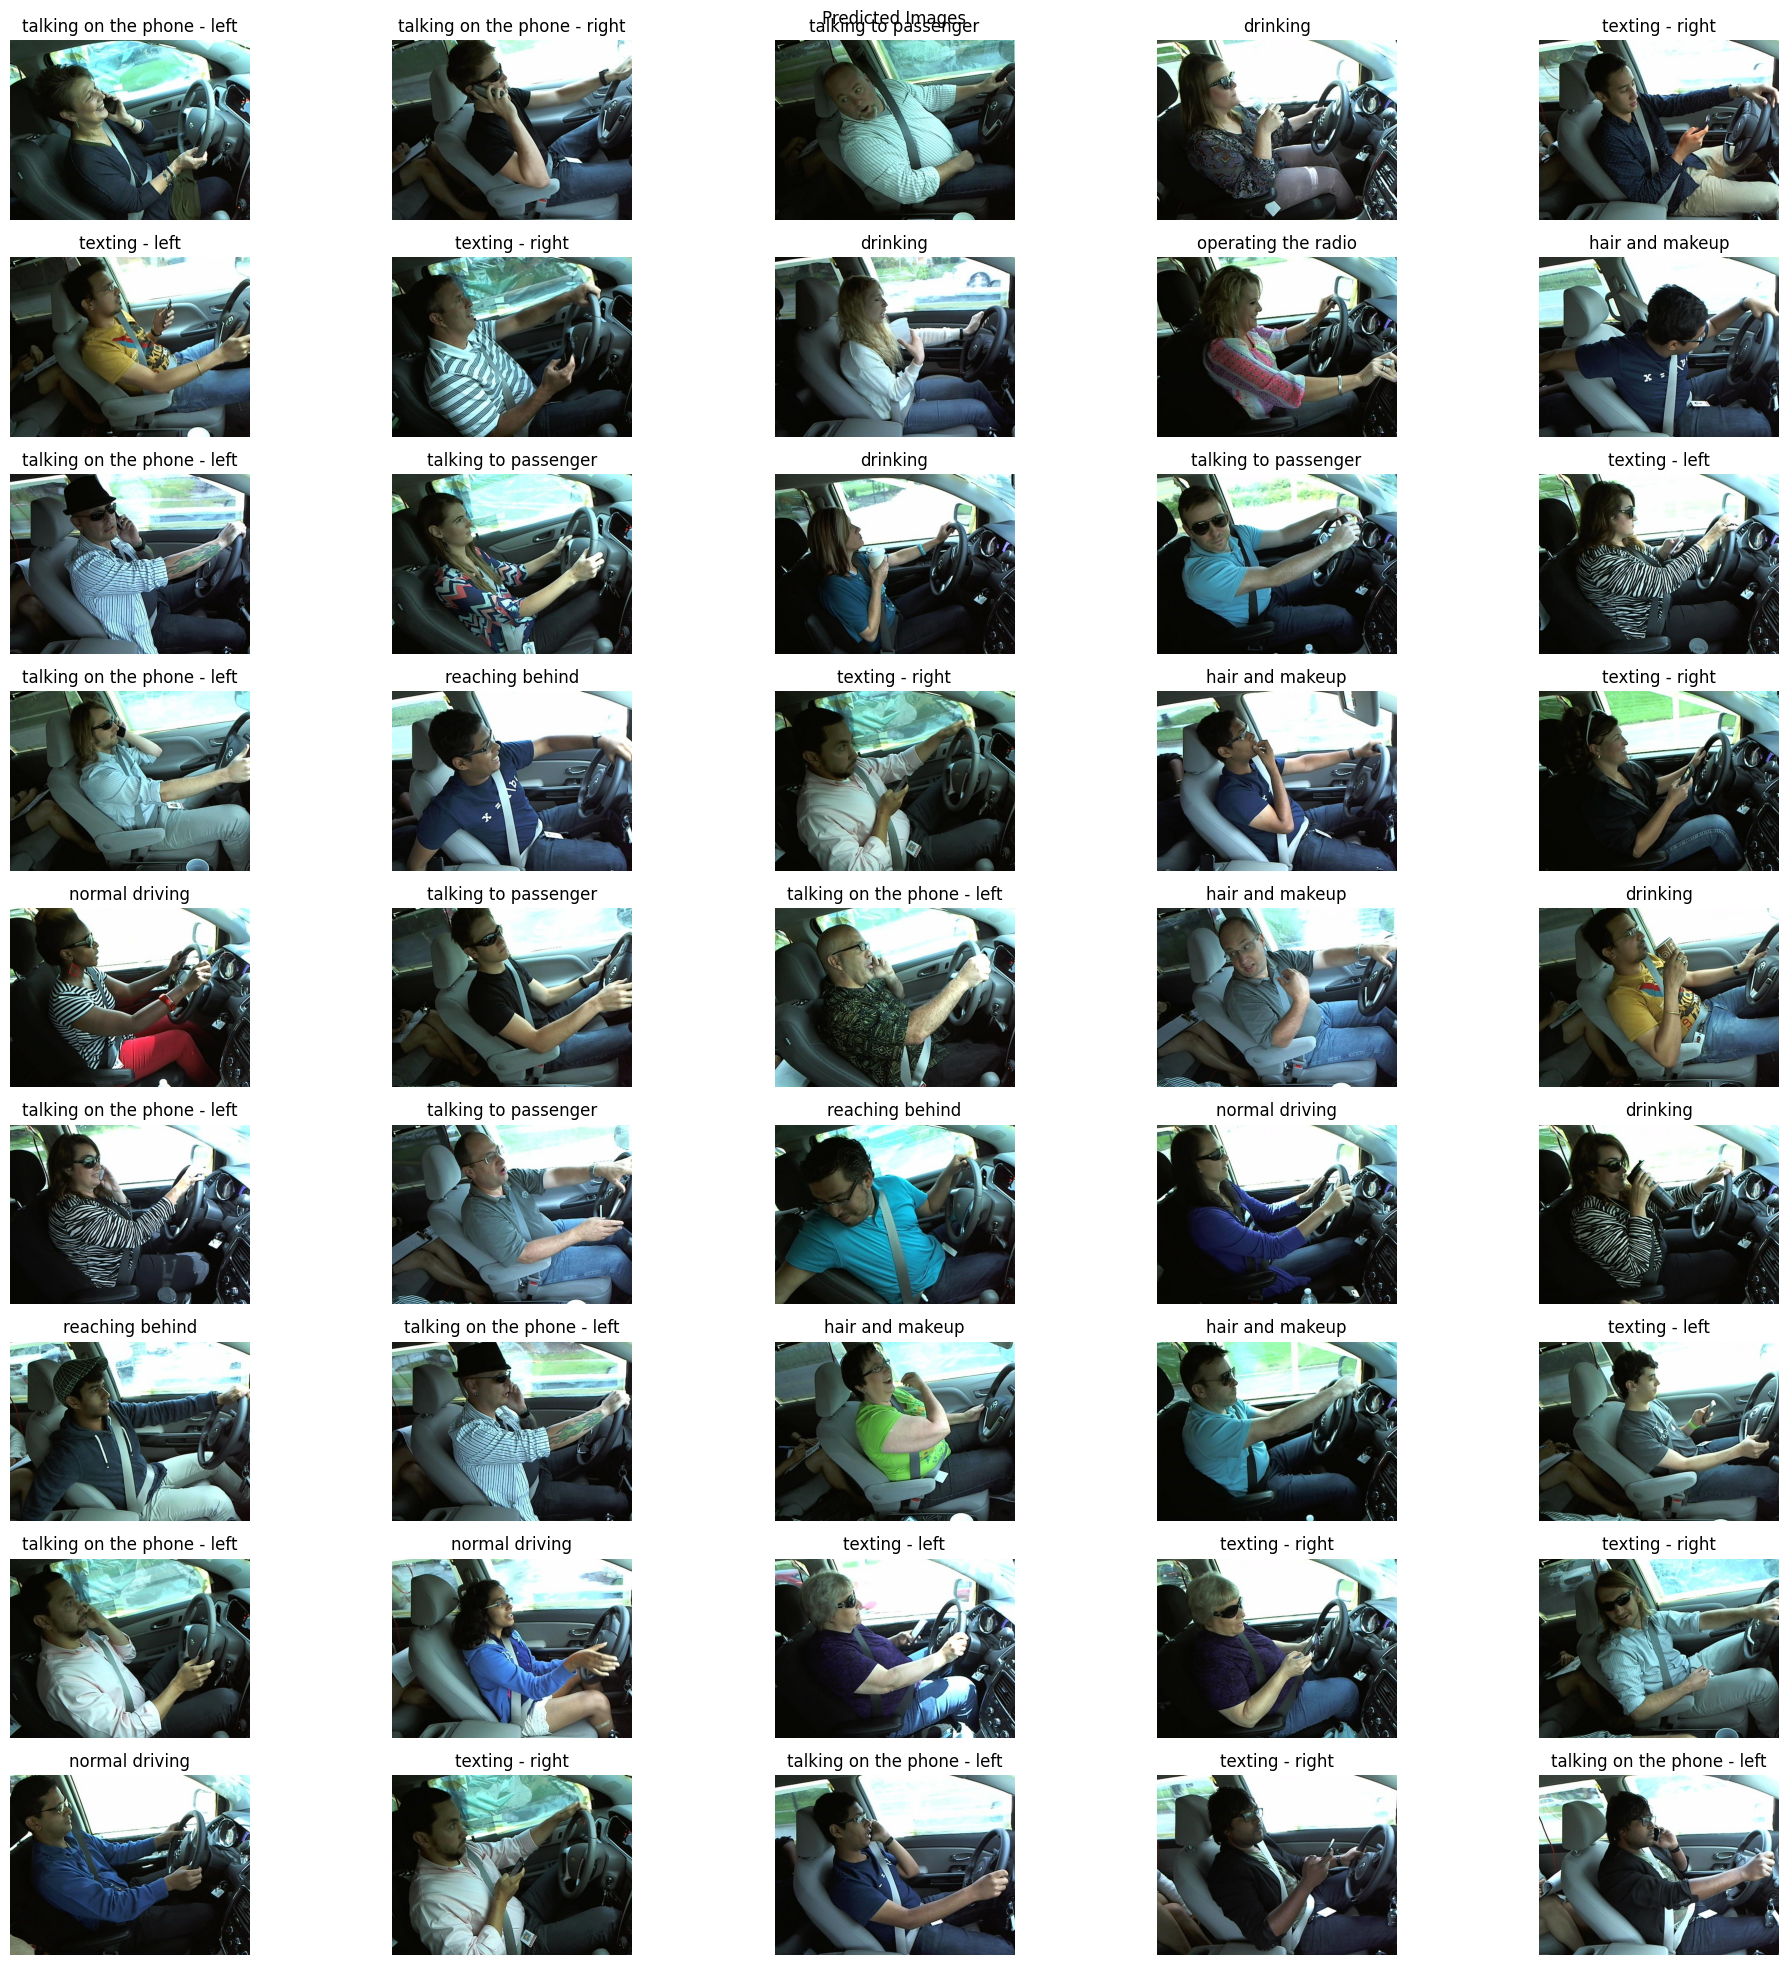

In [ ]:
rows = 9
cols = 5
fig, ax = plt.subplots(rows, cols, figsize=(20, 20))
for i, (img, label) in enumerate(pred):
    row = i // cols
    col = i % cols
    ax[row, col].imshow(plt.imread(img))
    ax[row, col].set_title(labels.get(label))
    ax[row, col].axis('off')

plt.suptitle("Predicted Images")
plt.tight_layout()
plt.show()